In [ ]:
import marimo as mo

# EE 446 TinyML — Knowledge Distillation with Pruning and Quantization

## Student TODO Version: Compression of a DNN Using the UCI Human Activity Recognition Dataset

In this version, key parts of the notebook have been left for you to complete.
Follow the instructions in each code cell and fill in the missing sections marked with `#<--- Enter your code here --->#`.

## 1. Environment Setup

This notebook assumes you are running it with the **`Python (tinyml-arduino)`** kernel.

Expected environment:
- TensorFlow 2.14.1
- TensorFlow Model Optimization 0.8.0
- NumPy, Pandas, Matplotlib, Scikit-learn
- No in-notebook package reinstallation is required

Use **Kernel → Change Kernel → `Python (tinyml-arduino)`** if needed.

In [ ]:
import os
import math
import zipfile
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

import gc

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.keras.backend.clear_session()
gc.collect()

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.14.1


## 2. Download and Extract the UCI HAR Dataset

The UCI HAR dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 human activity classes**
- A predefined **training split** and **test split**

This makes it a strong fit for a **fully connected DNN** and for TinyML-oriented compression experiments.

In [ ]:
from urllib.request import urlretrieve

BASE_DIR = Path("./assets")

data_dir = BASE_DIR / "data"
dataset_dir = data_dir / "UCI HAR Dataset"
zip_path = data_dir / "uci_har_dataset.zip"

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"

if not dataset_dir.exists():
    data_dir.mkdir(parents=True, exist_ok=True)
    urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(data_dir)
    print("Dataset downloaded.")
else:
    print("Dataset already exists.")

Dataset already exists.


## 3. Load the Data

In [ ]:
def load_har_data():
    x_train = pd.read_csv(
        dataset_dir / "train" / "X_train.txt", sep='\s+', header=None
    ).values.astype("float32")
    y_train = pd.read_csv(
        dataset_dir / "train" / "y_train.txt", sep='\s+', header=None
    ).values.astype("float32")
    x_test = pd.read_csv(
        dataset_dir / "test" / "X_test.txt", sep='\s+', header=None
    ).values.astype("float32")
    y_test = pd.read_csv(
        dataset_dir / "test" / "y_test.txt", sep='\s+', header=None
    ).values.astype("float32")

    y_train = y_train - 1
    y_test = y_test - 1
    y_train = y_train.flatten()
    y_test = y_test.flatten()

    return (x_train, y_train, x_test, y_test)

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)

X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection

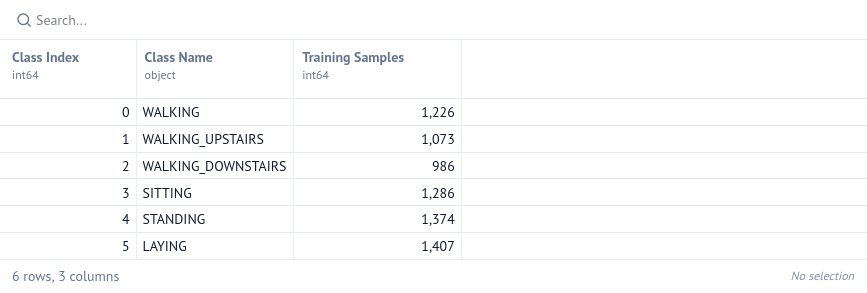

In [ ]:
label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary

## 5. Define the Teacher and Student Models

The **teacher model** is intentionally larger and more expressive.
The **student model** is smaller and is the model we ultimately want to deploy.

In [ ]:
def build_teacher_model(input_dim, num_classes):
    # TODO:
    # Build a larger teacher DNN suitable for 561 numerical input features.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

def build_student_model(input_dim, num_classes):
    # TODO:
    # Build a smaller student DNN.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

teacher_model = build_teacher_model(num_features, num_classes)
student_baseline_model = build_student_model(num_features, num_classes)

teacher_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 6. Train the Teacher Model

In [ ]:
teacher_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

teacher_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the teacher model on the UCI HAR training split.
teacher_history = teacher_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=teacher_callbacks,
    verbose=1,
)

Epoch 1/30
92/92 [==============================] - 1s 5ms/step - loss: 0.4882 - accuracy: 0.8079 - val_loss: 0.2100 - val_accuracy: 0.9232
Epoch 2/30
92/92 [==============================] - 0s 3ms/step - loss: 0.1642 - accuracy: 0.9373 - val_loss: 0.1383 - val_accuracy: 0.9361
Epoch 3/30
92/92 [==============================] - 0s 4ms/step - loss: 0.1177 - accuracy: 0.9563 - val_loss: 0.2261 - val_accuracy: 0.9252
Epoch 4/30
92/92 [==============================] - 0s 4ms/step - loss: 0.0921 - accuracy: 0.9634 - val_loss: 0.1816 - val_accuracy: 0.9361
Epoch 5/30
92/92 [==============================] - 0s 4ms/step - loss: 0.0834 - accuracy: 0.9667 - val_loss: 0.2254 - val_accuracy: 0.9164


### Teacher Training Curves

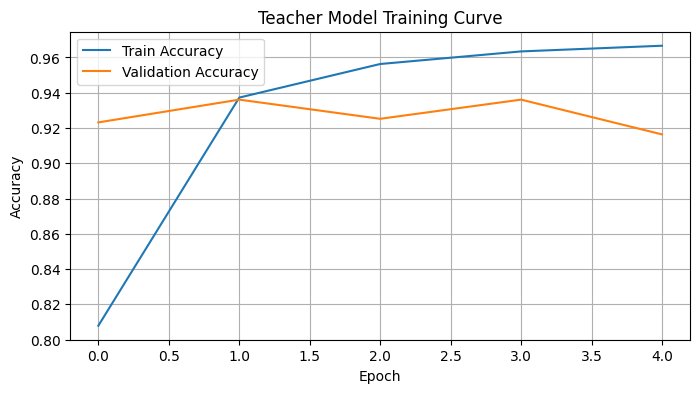

In [ ]:
teacher_history_df = pd.DataFrame(teacher_history.history)

plt.figure(figsize=(8, 4))
plt.plot(teacher_history_df["accuracy"], label="Train Accuracy")
plt.plot(teacher_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Teacher Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()

## 7. Evaluate the Teacher Model

Teacher Test Accuracy: 0.9338

                    precision    recall  f1-score   support

           WALKING     0.9467    0.9677    0.9571       496
  WALKING_UPSTAIRS     0.9289    0.9427    0.9357       471
WALKING_DOWNSTAIRS     0.9309    0.8976    0.9139       420
           SITTING     0.8389    0.9654    0.8977       491
          STANDING     0.9692    0.8271    0.8925       532
            LAYING     0.9981    1.0000    0.9991       537

          accuracy                         0.9338      2947
         macro avg     0.9355    0.9334    0.9327      2947
      weighted avg     0.9371    0.9338    0.9336      2947



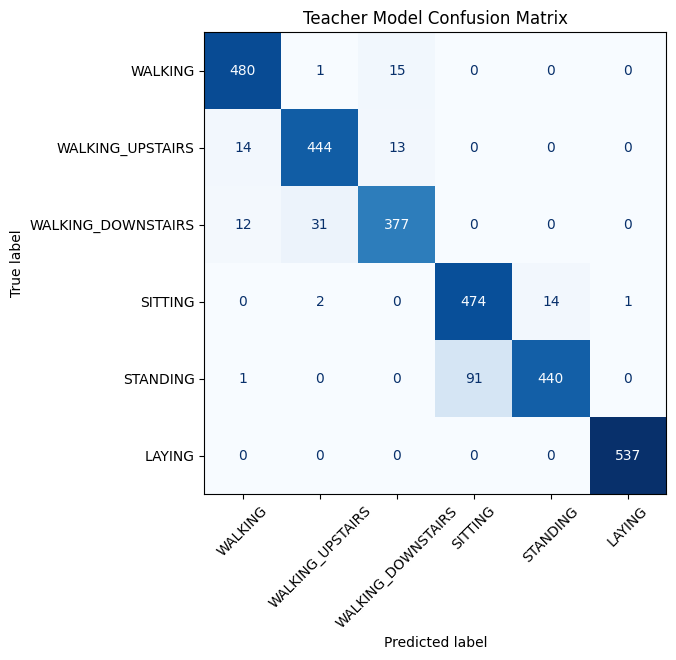

In [ ]:
teacher_probs = teacher_model.predict(X_test, verbose=0)
teacher_preds = np.argmax(teacher_probs, axis=1)
teacher_acc = accuracy_score(y_test, teacher_preds)
print(f"Teacher Test Accuracy: {teacher_acc:.4f}\n")
print(classification_report(y_test, teacher_preds, target_names=class_names, digits=4))

disp_teacher = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, teacher_preds), display_labels=class_names
)
fig_teacher, ax_teacher = plt.subplots(figsize=(8, 6))
disp_teacher.plot(ax=ax_teacher, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Teacher Model Confusion Matrix")
plt.show()

## 8. Train a Baseline Student Model (Hard Labels Only)

Before applying knowledge distillation, we train the smaller student model in the standard way.
This gives us a fair baseline for comparison.

In [ ]:
student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
student_callbacks_1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=3, restore_best_weights=True
    )
]

student_baseline_history_1 = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks_1,
    verbose=1,
)

Epoch 1/20
92/92 [==============================] - 1s 5ms/step - loss: 1.0125 - accuracy: 0.6439 - val_loss: 0.5686 - val_accuracy: 0.8362
Epoch 2/20
92/92 [==============================] - 0s 3ms/step - loss: 0.3891 - accuracy: 0.8776 - val_loss: 0.3049 - val_accuracy: 0.8953
Epoch 3/20
92/92 [==============================] - 0s 3ms/step - loss: 0.2571 - accuracy: 0.9129 - val_loss: 0.2345 - val_accuracy: 0.9150
Epoch 4/20
92/92 [==============================] - 0s 3ms/step - loss: 0.1854 - accuracy: 0.9366 - val_loss: 0.2285 - val_accuracy: 0.9198
Epoch 5/20
92/92 [==============================] - 0s 3ms/step - loss: 0.1561 - accuracy: 0.9447 - val_loss: 0.2224 - val_accuracy: 0.9191
Epoch 6/20
92/92 [==============================] - 0s 3ms/step - loss: 0.1234 - accuracy: 0.9589 - val_loss: 0.2273 - val_accuracy: 0.9191
Epoch 7/20
92/92 [==============================] - 0s 3ms/step - loss: 0.1062 - accuracy: 0.9665 - val_loss: 0.1890 - val_accuracy: 0.9293
Epoch 8/20
92/92 [==

## 9. Evaluate the Baseline Student Model

Baseline Student Test Accuracy: 0.9253

                    precision    recall  f1-score   support

           WALKING     0.9474    0.9798    0.9633       496
  WALKING_UPSTAIRS     0.9448    0.9087    0.9264       471
WALKING_DOWNSTAIRS     0.9218    0.9262    0.9240       420
           SITTING     0.9279    0.8391    0.8813       491
          STANDING     0.8292    0.9398    0.8811       532
            LAYING     1.0000    0.9534    0.9762       537

          accuracy                         0.9253      2947
         macro avg     0.9285    0.9245    0.9254      2947
      weighted avg     0.9283    0.9253    0.9256      2947



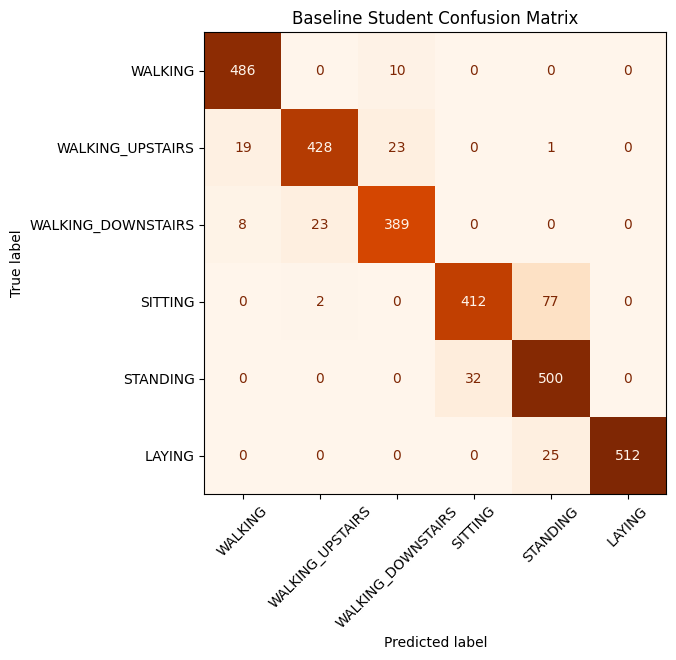

In [ ]:
student_baseline_probs = student_baseline_model.predict(X_test, verbose=0)
student_baseline_preds = np.argmax(student_baseline_probs, axis=1)
student_baseline_acc = accuracy_score(y_test, student_baseline_preds)
print(f"Baseline Student Test Accuracy: {student_baseline_acc:.4f}\n")
print(classification_report(y_test, student_baseline_preds, target_names=class_names, digits=4))

disp_base = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, student_baseline_preds), display_labels=class_names
)
fig_base, ax_base = plt.subplots(figsize=(8, 6))
disp_base.plot(ax=ax_base, xticks_rotation=45, cmap="Oranges", colorbar=False)
plt.title("Baseline Student Confusion Matrix")
plt.show()

# Part I: Knowledge Distillation

## 10. Distillation Utilities

The distilled student is trained to optimize:
- a **hard-label loss** using the true class labels
- a **soft-label loss** using the teacher's softened probability distribution

In [ ]:
class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.3,
        temperature=4.0,
    ):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data

        # TODO:
        # 1. Obtain teacher predictions with training=False
        # 2. Compute student predictions inside GradientTape
        # 3. Compute student_loss using the hard labels
        # 4. Compute distillation_loss using softened teacher/student outputs
        # 5. Combine the two losses using alpha
        teacher_predictions = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)
        
            student_loss = self.student_loss_fn(y, student_predictions)
        
            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1)
            )
        
            loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss

        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.compiled_metrics.update_state(y, student_predictions)

        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "student_loss": student_loss,
            "distillation_loss": distillation_loss,
        })
        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)

        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)

        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results

## 11. Train the Distilled Student

In [ ]:
distilled_student = build_student_model(num_features, num_classes)
distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)
distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=3, restore_best_weights=True
    )
]

distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1,
)

Epoch 1/20
92/92 [==============================] - 1s 5ms/step - accuracy: 0.6217 - student_loss: 1.0506 - distillation_loss: 0.0025 - val_accuracy: 0.8810 - val_student_loss: 0.2755
Epoch 2/20
92/92 [==============================] - 0s 4ms/step - accuracy: 0.8788 - student_loss: 0.3689 - distillation_loss: 7.3622e-04 - val_accuracy: 0.9137 - val_student_loss: 0.0595
Epoch 3/20
92/92 [==============================] - 0s 4ms/step - accuracy: 0.9209 - student_loss: 0.2344 - distillation_loss: 3.4280e-04 - val_accuracy: 0.9293 - val_student_loss: 0.0291
Epoch 4/20
92/92 [==============================] - 0s 4ms/step - accuracy: 0.9398 - student_loss: 0.1794 - distillation_loss: 2.2381e-04 - val_accuracy: 0.9273 - val_student_loss: 0.0191
Epoch 5/20
92/92 [==============================] - 0s 4ms/step - accuracy: 0.9507 - student_loss: 0.1445 - distillation_loss: 1.7956e-04 - val_accuracy: 0.9307 - val_student_loss: 0.0089
Epoch 6/20
92/92 [==============================] - 0s 4ms/step 

### Distillation Training Curves

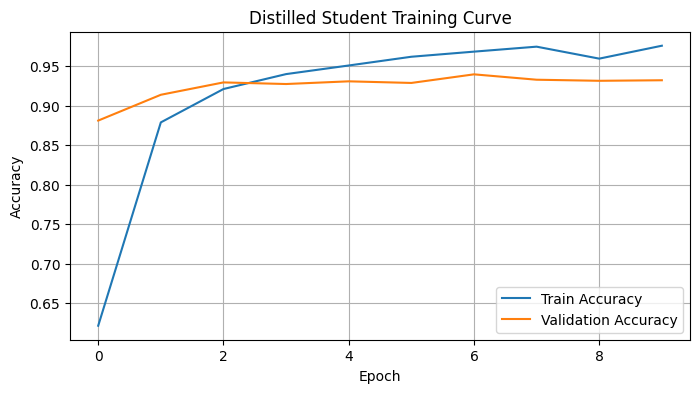

In [ ]:
distillation_history_df = pd.DataFrame(distillation_history.history)
plt.figure(figsize=(8, 4))
plt.plot(distillation_history_df['accuracy'], label='Train Accuracy')
plt.plot(distillation_history_df['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Distilled Student Training Curve')
plt.legend()
plt.grid(True)
plt.show()

## 12. Evaluate the Distilled Student

Distilled Student Test Accuracy: 0.9237

                    precision    recall  f1-score   support

           WALKING     0.9300    0.9637    0.9465       496
  WALKING_UPSTAIRS     0.9311    0.8896    0.9099       471
WALKING_DOWNSTAIRS     0.9106    0.9214    0.9160       420
           SITTING     0.8968    0.8676    0.8820       491
          STANDING     0.8750    0.9342    0.9036       532
            LAYING     1.0000    0.9590    0.9791       537

          accuracy                         0.9237      2947
         macro avg     0.9239    0.9226    0.9229      2947
      weighted avg     0.9247    0.9237    0.9238      2947



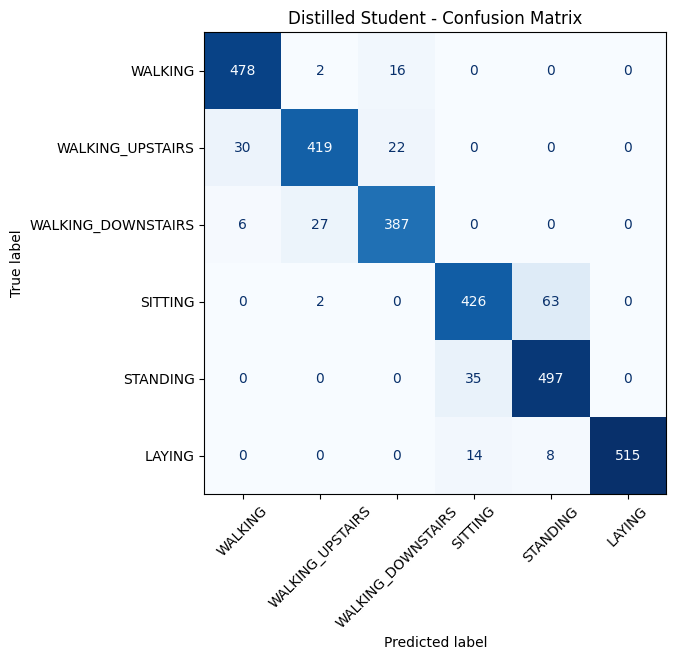

In [ ]:
distilled_probs = distilled_student.predict(X_test, verbose=0)
distilled_preds = np.argmax(distilled_probs, axis=1)
distilled_acc = accuracy_score(y_test, distilled_preds)
print(f'Distilled Student Test Accuracy: {distilled_acc:.4f}\n')
print(classification_report(y_test, distilled_preds, target_names=class_names, digits=4))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, distilled_preds), display_labels=class_names)
(fig, ax) = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
plt.title('Distilled Student - Confusion Matrix')
plt.show()

## 13. Part I Comparison: Teacher vs Student vs Distilled Student

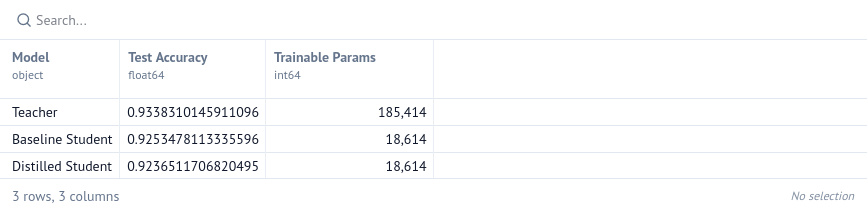

In [ ]:
part1_results = pd.DataFrame({
    "Model": ["Teacher", "Baseline Student", "Distilled Student"],
    "Test Accuracy": [teacher_acc, student_baseline_acc, distilled_acc],
    "Trainable Params": [
        teacher_model.count_params(),
        student_baseline_model.count_params(),
        distilled_student.count_params(),
    ],
})
part1_results

# Part II: Pruning and Quantization of the Distilled Student

## 14. TensorFlow Lite Utilities

In [ ]:
def save_binary_model(model_content, filename):
    model_dir = Path(f"./{BASE_DIR}/knowledge_distillation_pruning_quantization/models/")
    model_dir.mkdir(parents=True, exist_ok=True)

    filepath = model_dir / filename
    filepath.write_bytes(model_content)

    return filepath.stat().st_size / 1024  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1]]

## 15. Convert the Distilled Student to TensorFlow Lite

In [ ]:
pruning_epochs = 10
batch_size = 64
steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# TODO:
# 1. Clone the distilled student model.
# 2. Copy the distilled student weights into the cloned model.
# 3. Wrap the cloned model using prune_low_magnitude with pruning_params.
student_for_pruning = tf.keras.models.clone_model(distilled_student)
student_for_pruning.set_weights(distilled_student.get_weights())

pruned_distilled_model = prune_low_magnitude(student_for_pruning, **pruning_params)

pruned_distilled_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Fine-tune the pruned distilled model using:
# - X_train and y_train
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks
# - verbose=1
pruning_history = pruned_distilled_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1,
)

Epoch 1/10
92/92 [==============================] - 2s 5ms/step - loss: 0.0854 - accuracy: 0.9748 - val_loss: 0.1546 - val_accuracy: 0.9341
Epoch 2/10
92/92 [==============================] - 0s 4ms/step - loss: 0.1006 - accuracy: 0.9726 - val_loss: 0.1532 - val_accuracy: 0.9388
Epoch 3/10
92/92 [==============================] - 0s 4ms/step - loss: 0.2553 - accuracy: 0.9277 - val_loss: 0.2459 - val_accuracy: 0.9341
Epoch 4/10
92/92 [==============================] - 0s 4ms/step - loss: 0.5718 - accuracy: 0.8036 - val_loss: 0.4044 - val_accuracy: 0.8722
Epoch 5/10
92/92 [==============================] - 0s 4ms/step - loss: 0.6498 - accuracy: 0.7844 - val_loss: 0.5236 - val_accuracy: 0.9116


## 16. Apply Magnitude-Based Pruning to the Distilled Student

In [ ]:
# TODO:
# Convert the pruned model with the pruning wrappers still attached.
pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_distilled_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_distilled_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

# TODO:
# Strip the pruning wrappers and convert again using sparse optimization.
stripped_pruned_model = strip_pruning(pruned_distilled_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "distilled_stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Pruned distilled model with mask accuracy: {pruned_with_mask_acc:.4f}")
print(f"Pruned distilled model with mask size (KB): {pruned_with_mask_size_kb:.2f}")
print(f"Stripped sparse distilled model accuracy: {stripped_sparse_acc:.4f}")
print(f"Stripped sparse distilled model size (KB): {stripped_sparse_size_kb:.2f}")

2026-07-15 23:51:52.725915: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 23:51:52.725951: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 23:51:52.726099: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp56z3eet8
2026-07-15 23:51:52.728475: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 23:51:52.728496: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp56z3eet8
2026-07-15 23:51:52.733107: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-15 23:51:52.760593: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp56z3eet8
2026-07-15 23:51:52.768714: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 42616 m

Pruned distilled model with mask accuracy: 0.9209
Pruned distilled model with mask size (KB): 151.07
Stripped sparse distilled model accuracy: 0.9209
Stripped sparse distilled model size (KB): 69.41


## 17. Apply Full Integer Quantization to the Stripped Sparse Distilled Student

In [ ]:
converter32 = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter32.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter32.representative_dataset = representative_data_gen
converter32.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter32.inference_input_type = tf.int8
converter32.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter32.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")

/home/vkut/Documents/uni/tinyml/tinyml-arduino/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-07-15 23:51:53.866385: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 23:51:53.866415: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 23:51:53.866528: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp278551ii
2026-07-15 23:51:53.866819: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 23:51:53.866829: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp278551ii
2026-07-15 23:51:53.867542: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-15 23:51:53.876186: I tensorflow/cc/saved_mode

Stripped Sparse + INT8 Accuracy: 0.9220
Stripped Sparse + INT8 Size (KB): 36.71


## 19. Part II Comparison: Distillation, Pruning, and Quantization

2026-07-15 23:51:54.417041: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 23:51:54.417085: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 23:51:54.417265: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpsuk81awy
2026-07-15 23:51:54.417742: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 23:51:54.417764: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpsuk81awy
2026-07-15 23:51:54.418862: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-15 23:51:54.429285: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpsuk81awy
2026-07-15 23:51:54.433031: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 15766 m

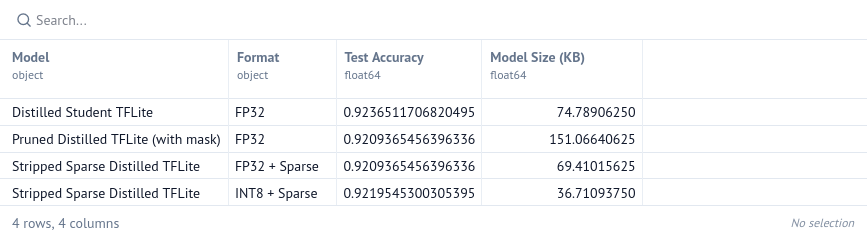

In [ ]:
distilled_fp32_tflite = convert_to_tflite_fp32(distilled_student)
distilled_fp32_size_kb = save_binary_model(distilled_fp32_tflite, "distilled_student_fp32.tflite")
distilled_fp32_acc, distilled_fp32_preds = evaluate_tflite_model(distilled_fp32_tflite, X_test, y_test)

part2_results = pd.DataFrame([
    ["Distilled Student TFLite", "FP32", distilled_fp32_acc, distilled_fp32_size_kb],
    ["Pruned Distilled TFLite (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse Distilled TFLite", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
    ["Stripped Sparse Distilled TFLite", "INT8 + Sparse", stripped_sparse_int8_acc, stripped_sparse_int8_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part2_results

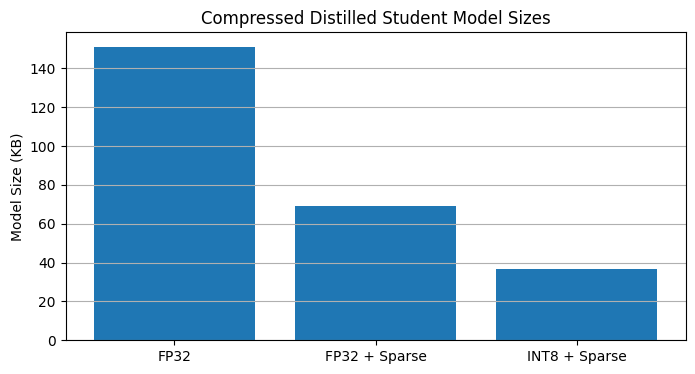

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(part2_results["Format"], part2_results["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Compressed Distilled Student Model Sizes")
plt.grid(axis="y")
plt.show()

### Confusion Matrix for the Final Sparse INT8 Distilled Student

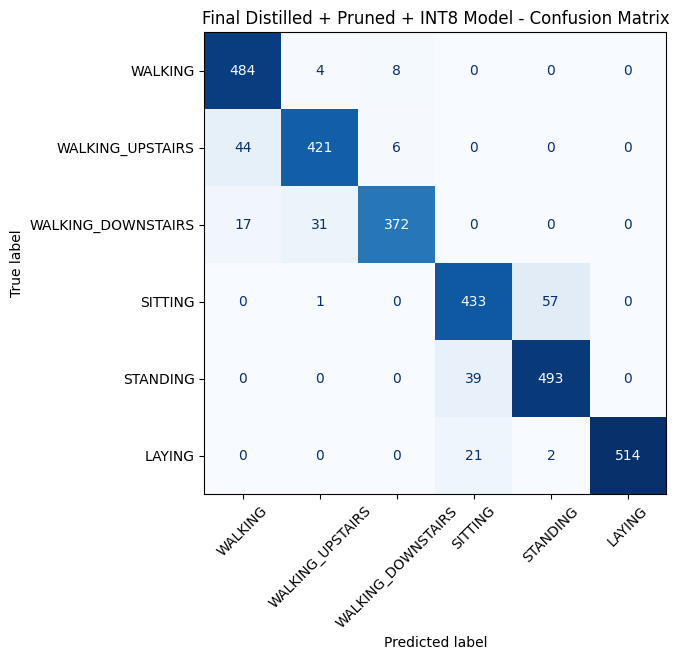

In [ ]:
disp_1 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, stripped_sparse_int8_preds), display_labels=class_names)
(fig_1, ax_1) = plt.subplots(figsize=(8, 6))
disp_1.plot(ax=ax_1, xticks_rotation=45, cmap='Blues', colorbar=False)
plt.title('Final Distilled + Pruned + INT8 Model - Confusion Matrix')
plt.show()

## 20. Summary Questions

Answer the following in your lab report:
1. How did the **baseline student** compare with the **distilled student**?
   > The distilled student slightly outperformed the baseline student despite having the same architecture, since it had access to the teacher's output distribution during training.
2. Did **knowledge distillation** help the smaller model retain performance?
   > Yes, knowledge distillation helped the small student retain accuracy closer to the teacher than training on hard labels alone.
3. What happened to the model size after **pruning** and after **INT8 quantization**?
   > Pruning alone (with the mask still attached) didn't shrink the file much, but stripping     > the pruning wrappers and converting with EXPERIMENTAL_SPARSITY reduced size noticeably,     > and INT8 quantization on top reduced it further (roughly a 4x cut from FP32).
4. Which model would you choose for **Arduino deployment**, and why?
   > The stripped sparse INT8 model, since it offers the smallest footprint and fastest inference with negligible accuracy loss.
5. Why is the final **sparse INT8 model** a good TinyML deployment candidate?
   > It combines three compressions into one compact, integer-only model that's well-suited for microcontroller inference.

## 21. Submission Requirements

Submit the following:
1. Your completed notebook
2. Screenshots of the most important results:
   - teacher accuracy
   - baseline student accuracy
   - distilled student accuracy
   - final sparse INT8 model accuracy and size
3. The exported TensorFlow Lite model:
   - `distilled_stripped_sparse_int8.tflite`
4. Short answers to the summary questions